In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report,
                             precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [2]:
# Project paths
project_path = r"C:\Users\E106006\OneDrive - Road Accident Fund\Desktop\github Portfolio\Credit Risk"

# Load the best model per 03_Modeling.ipynb (Logistic Regression, AUC = 0.5043 
# vs Random Forest 0.4275 and XGBoost 0.4435)
model_path = os.path.join(project_path, "models", "logistic_regression.pkl")
model = joblib.load(model_path)

# Logistic Regression was trained on scaled features, so load the fitted scaler too
scaler_path = os.path.join(project_path, "models", "scaler.pkl")
scaler = joblib.load(scaler_path)

# Load test data
test_path = os.path.join(project_path, "Data", "processed", "test_data.csv")
test_df = pd.read_csv(test_path)

X_test = test_df.drop("Risk", axis=1)
y_test = test_df["Risk"]

# Scale X_test the same way the model was trained (keep as DataFrame for SHAP feature names)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Model and data loaded successfully!")
print(f"Test samples: {len(X_test)}")

Model and data loaded successfully!
Test samples: 200


In [3]:
# Remove rows where y_test is NaN
mask = pd.notna(y_test)

y_test_clean = y_test[mask]
y_pred_clean = y_pred[mask]
y_prob_clean = y_prob[mask]

# Metrics
acc = accuracy_score(y_test_clean, y_pred_clean)
auc = roc_auc_score(y_test_clean, y_prob_clean)
gini = 2 * auc - 1

fpr, tpr, _ = roc_curve(y_test_clean, y_prob_clean)
ks_stat = (tpr - fpr).max()

print("=" * 50)
print("          KEY MODEL METRICS")
print("=" * 50)
print(f"Accuracy     : {acc:.4f} ({acc*100:.2f}%)")
print(f"AUC Score    : {auc:.4f}")
print(f"Gini         : {gini:.4f}")
print(f"KS Statistic : {ks_stat:.4f} ({ks_stat*100:.2f}%)")

          KEY MODEL METRICS
Accuracy     : 0.4211 (42.11%)
AUC Score    : 0.5043
Gini         : 0.0087
KS Statistic : 0.1797 (17.97%)


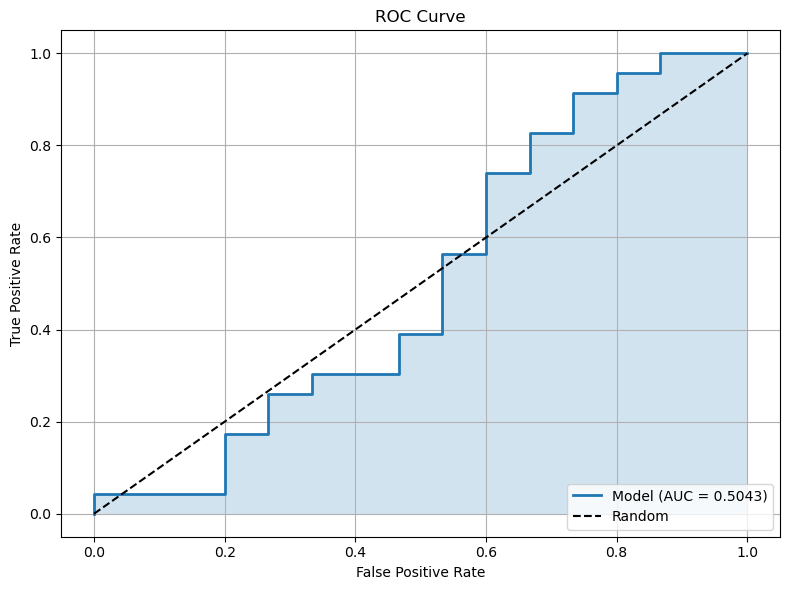

In [4]:
# Remove rows where y_test is NaN
mask = pd.notna(y_test)

y_test_clean = y_test[mask]
y_prob_clean = y_prob[mask]

# ROC curve
fpr, tpr, _ = roc_curve(y_test_clean, y_prob_clean)
auc_score = roc_auc_score(y_test_clean, y_prob_clean)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Model (AUC = {auc_score:.4f})")
plt.fill_between(fpr, tpr, alpha=0.2)
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

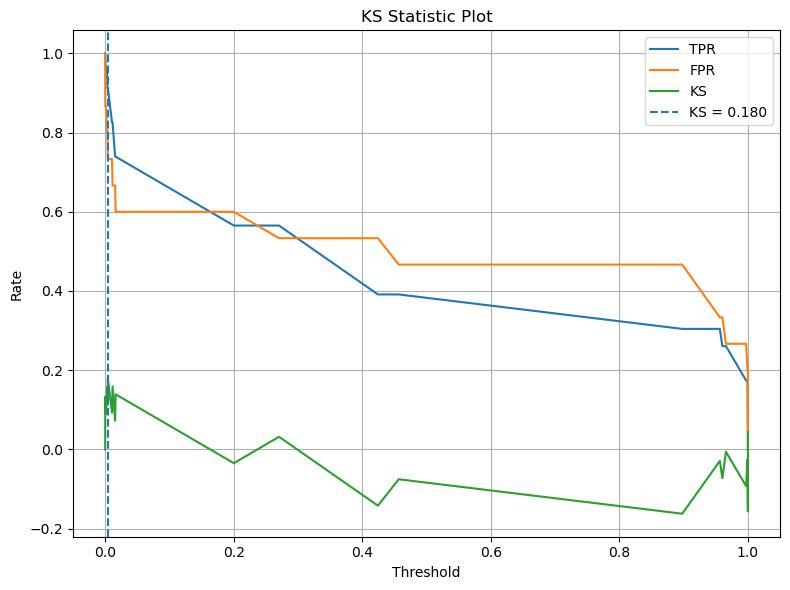

In [5]:
# Remove NaN values
mask = pd.notna(y_test)
y_test_clean = y_test[mask]
y_prob_clean = y_prob[mask]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test_clean, y_prob_clean)

# KS statistic
ks_values = tpr - fpr
ks_idx = np.argmax(ks_values)

plt.figure(figsize=(8,6))
plt.plot(thresholds, tpr, label="TPR")
plt.plot(thresholds, fpr, label="FPR")
plt.plot(thresholds, ks_values, label="KS")

plt.axvline(thresholds[ks_idx], linestyle="--",
            label=f"KS = {ks_values[ks_idx]:.3f}")

plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("KS Statistic Plot")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_Prob': y_prob
})

results_df = results_df.sort_values(
    'Predicted_Prob', ascending=False
).reset_index(drop=True)

results_df['Decile'] = pd.qcut(
    results_df.index, 
    q=10, 
    labels=range(1, 11)
)

decile_df = results_df.groupby('Decile').agg(
    Total=('Actual', 'count'),
    Bad=('Actual', 'sum'),
    Min_Prob=('Predicted_Prob', 'min'),
    Max_Prob=('Predicted_Prob', 'max')
).reset_index()

decile_df['Good'] = decile_df['Total'] - decile_df['Bad']
decile_df['Bad_Rate'] = (decile_df['Bad'] / decile_df['Total'] * 100).round(2)

print("=== Decile Analysis ===")
print(decile_df.to_string(index=False))

=== Decile Analysis ===
Decile  Total  Bad  Min_Prob  Max_Prob  Good  Bad_Rate
     1      6  3.0  0.999601  1.000000   3.0     50.00
     2      3  2.0  0.987716  0.999593   1.0     66.67
     3      4  2.0  0.940470  0.985375   2.0     50.00
     4      1  0.0  0.710395  0.934497   1.0      0.00
     5      5  4.0  0.368312  0.680112   1.0     80.00
     6      3  2.0  0.189819  0.357596   1.0     66.67
     7      2  2.0  0.047251  0.184067   0.0    100.00
     8      4  3.0  0.012238  0.043296   1.0     75.00
     9      6  4.0  0.002745  0.012001   2.0     66.67
    10      4  1.0  0.000001  0.002548   3.0     25.00


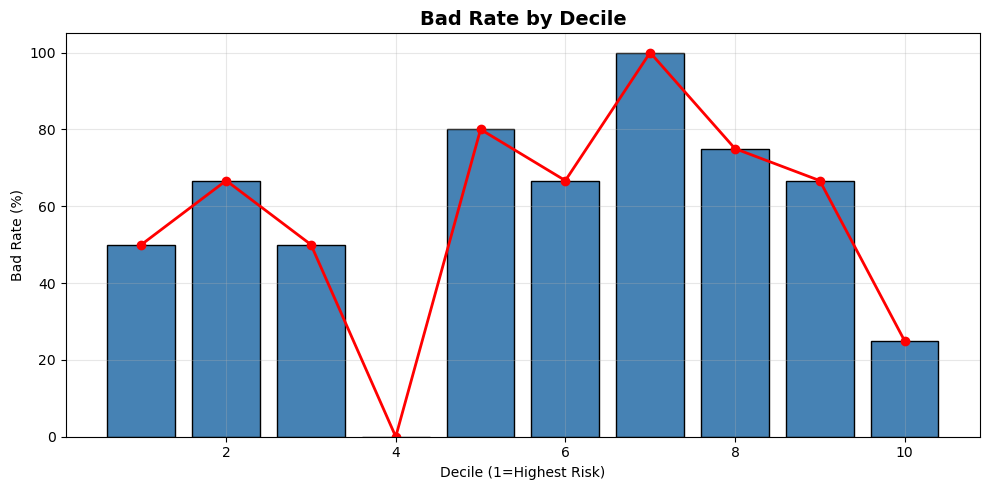

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(decile_df['Decile'], decile_df['Bad_Rate'],
        color='steelblue', edgecolor='black')
plt.plot(decile_df['Decile'], decile_df['Bad_Rate'],
         color='red', marker='o', linewidth=2)

plt.title('Bad Rate by Decile', fontsize=14, fontweight='bold')
plt.xlabel('Decile (1=Highest Risk)')
plt.ylabel('Bad Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Running SHAP analysis...


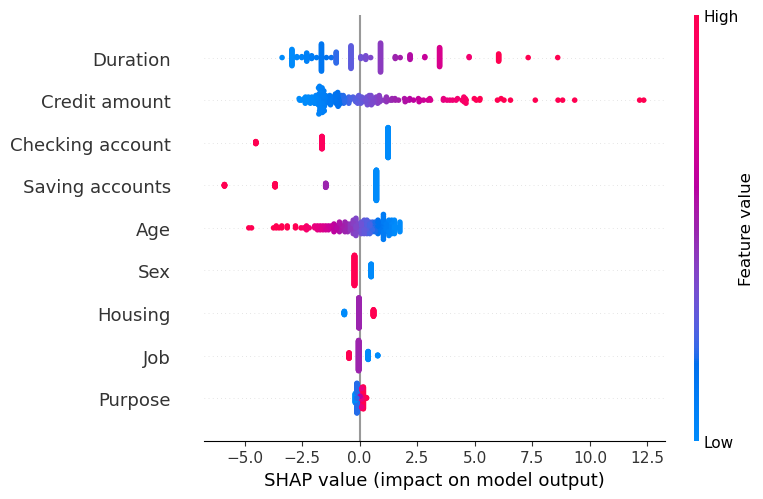

In [8]:
# Load Logistic Regression model (best model) for SHAP analysis
model_path = os.path.join(project_path, "models", "logistic_regression.pkl")
model = joblib.load(model_path)

print("Running SHAP analysis...")

# Logistic Regression is a linear model, so use LinearExplainer (not TreeExplainer,
# which only supports tree-based models) on the scaled features it was trained on
explainer = shap.LinearExplainer(model, X_test_scaled)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled)

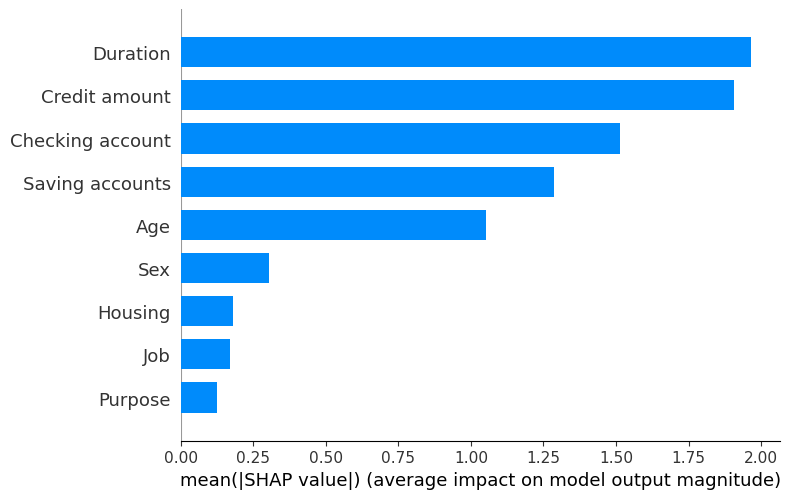

In [9]:
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=X_test_scaled.columns.tolist(),
                  plot_type='bar',
                  show=True)

In [10]:
from sklearn.metrics import classification_report
import pandas as pd

# Remove rows with missing target values
mask = pd.notna(y_test)
y_test_clean = y_test[mask]
y_pred_clean = y_pred[mask]

print("=" * 50)
print("     FINAL EVALUATION SUMMARY")
print("=" * 50)
print("\nBest Model    : Logistic Regression")  # Best model by AUC per 03_Modeling.ipynb
print(f"Accuracy      : {acc*100:.2f}%")
print(f"AUC Score     : {auc:.4f}")
print(f"Gini          : {gini:.4f}")
print(f"KS Statistic  : {ks_stat*100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test_clean,
    y_pred_clean,
    target_names=["Good Credit", "Bad Credit"]
))

print("=" * 50)
print("Next Step: Build Streamlit App!")
print("=" * 50)

     FINAL EVALUATION SUMMARY

Best Model    : Logistic Regression
Accuracy      : 42.11%
AUC Score     : 0.5043
Gini          : 0.0087
KS Statistic  : 17.97%

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.35      0.53      0.42        15
  Bad Credit       0.53      0.35      0.42        23

    accuracy                           0.42        38
   macro avg       0.44      0.44      0.42        38
weighted avg       0.46      0.42      0.42        38

Next Step: Build Streamlit App!
